In [2]:
# Подавление предупреждений
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

# Импорт необходимых библиотек
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import polars as pl
import pandas as pd
import sklearn
import networkx as nx
import jupyterlab as jlab
import ipywidgets
import torch.optim as optim
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.dates as mdates
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter
from torch.utils.data import TensorDataset, DataLoader

## Домашнее задание № 5: 


### Домашнее задание: Обучение и визуализация трансформера

### Цель задания

1. Обучить простую модель трансформера для обработки любых данных (на выбор: текст, аудио, видео, изображения и ...)



Загрузим датасет `emotion` с Hugging Face, который содержит тексты, классифицированные по 6 эмоциям:
- 0: _sadness_
- 1: _joy_
- 2: _love_
- 3: _anger_
- 4: _fear_
- 5: _surprise_

In [3]:
dataset = load_dataset("dair-ai/emotion")

In [4]:
print(dataset)

print("Текст:", dataset['train'][0]['text'])
print('Метка:', dataset['train'][0]['label'])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Текст: i didnt feel humiliated
Метка: 0


In [5]:
X_train = dataset['train']['text']
y_train = dataset['train']['label']

X_test = dataset['test']['text']
y_test = dataset['test']['label']

X_train = X_train[:5000]
y_train = y_train[:5000]

X_test = X_test[:1500]
y_test = y_test[:1500]

print(f"Размер трейн выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер трейн выборки: 5000


Размер тестовой выборки: 1500


In [6]:

MAX_VOCAB_SIZE = 10000
MAX_LEN = 20
embedding_dim = 128

counter = Counter()
for text in X_train:
    counter.update(text.lower().split())

vocab = {"<PAD>": 0, "<UNK>": 1}

for word, _ in counter.most_common(MAX_VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

def encode(text):
    tokens = text.lower().split()
    indices = [vocab.get(token, vocab["<UNK>"]) for token in tokens]

    indices = indices[:MAX_LEN]
    if len(indices) < MAX_LEN:
        indices += [vocab["<PAD>"]] * (MAX_LEN - len(indices))
    return indices

X_train_encoded = [encode(text) for text in X_train]
X_test_encoded  = [encode(text) for text in X_test]

X_train_tensor = torch.tensor(X_train_encoded, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_encoded, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

vocab_size=len(vocab)

train_data = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
test_data = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

In [7]:
class TransformerModelWithAttention(nn.Module):
    def __init__(self, input_dim, num_classes, num_heads=4, num_layers=2, hidden_dim=128, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, hidden_dim, padding_idx=0)
        self.positional_encoding = nn.Parameter(torch.zeros(1, 75, hidden_dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim*4, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc_out = nn.Linear(hidden_dim, num_classes)
        self.attention_weights=[]

    def forward(self, x):
    
        batch_size, seq_len = x.size()
        x = self.embedding(x)
        x = x + self.positional_encoding[:, :seq_len, :]

        encoder_output = self.transformer_encoder(x)
        
        self.attention_weights = []

        for layer in self.transformer_encoder.layers:
            attention_output, attn_weights = layer.self_attn(x, x, x, need_weights=True, average_attn_weights=False)
            self.attention_weights.append(attn_weights.detach().cpu())
        x = encoder_output.mean(dim=1)
        return self.fc_out(x)


Эпоха 1/30 , потери: 1.5534 , точность: 0.4060
Эпоха 2/30 , потери: 1.1154 , точность: 0.6340
Эпоха 3/30 , потери: 0.6903 , точность: 0.7033
Эпоха 4/30 , потери: 0.4597 , точность: 0.7160
Эпоха 5/30 , потери: 0.2958 , точность: 0.7400
Эпоха 6/30 , потери: 0.1948 , точность: 0.7207
Эпоха 7/30 , потери: 0.1639 , точность: 0.7227
Эпоха 8/30 , потери: 0.1089 , точность: 0.7153
Эпоха 9/30 , потери: 0.0863 , точность: 0.7280
Эпоха 10/30 , потери: 0.0817 , точность: 0.7313
Эпоха 11/30 , потери: 0.0848 , точность: 0.7293
Эпоха 12/30 , потери: 0.0639 , точность: 0.7213
Эпоха 13/30 , потери: 0.0671 , точность: 0.7233
Эпоха 14/30 , потери: 0.0573 , точность: 0.7300
Эпоха 15/30 , потери: 0.0577 , точность: 0.7313
Эпоха 16/30 , потери: 0.0439 , точность: 0.7353
Эпоха 17/30 , потери: 0.0406 , точность: 0.7347
Эпоха 18/30 , потери: 0.0295 , точность: 0.7340
Эпоха 19/30 , потери: 0.0312 , точность: 0.7180
Эпоха 20/30 , потери: 0.0550 , точность: 0.7313
Эпоха 21/30 , потери: 0.0457 , точность: 0.7460
Э

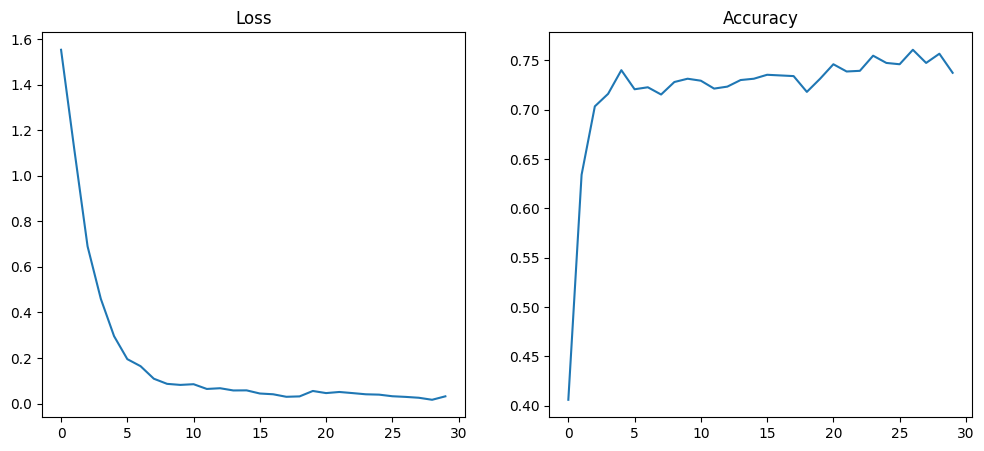

Финальная точность: 0.7373333333333333


In [8]:
model = TransformerModelWithAttention(input_dim=vocab_size, num_classes=6, hidden_dim=128).to('cpu')
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

losses = []
accuracies = []

def evaluate(model, test):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_test, y_test in test:
            X_test, y_test = X_test.to('cpu'), y_test.to('cpu')
            output = model(X_test)
            preds = output.argmax(dim=1)
            correct += (preds == y_test).sum().item()
            total += y_test.size(0)
    return correct/total


def train_with_logging(model, train, test, optimizer, criterion, epochs=10):

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for X_train, y_train in train:
            X_train, y_train = X_train.to('cpu'), y_train.to('cpu')
            optimizer.zero_grad()
            output = model(X_train)
            loss = criterion(output, y_train)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss/len(train)
        acc = evaluate(model, test)
        losses.append(avg_loss)
        accuracies.append(acc)
        print(f"Эпоха {epoch+1}/{epochs} , потери: {avg_loss:.4f} , точность: {acc:.4f}")


train_with_logging(model, train_data, test_data, optimizer, criterion, epochs=30)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(losses)
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(accuracies)
plt.title("Accuracy")

plt.show()

accuracy = evaluate(model, test_data)
print("Финальная точность:", accuracy)

2. Визуализировать веса внимания и интерпретировать их


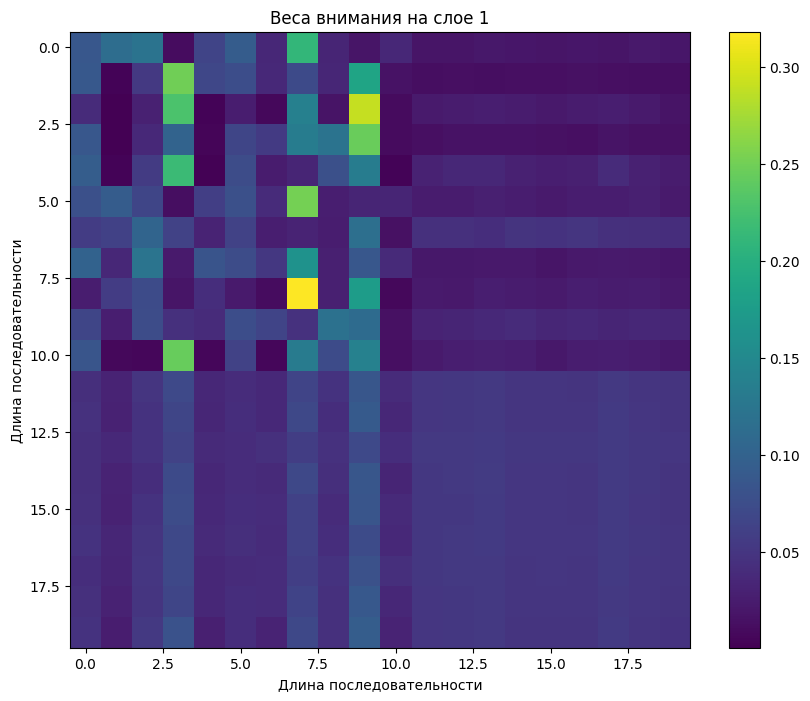

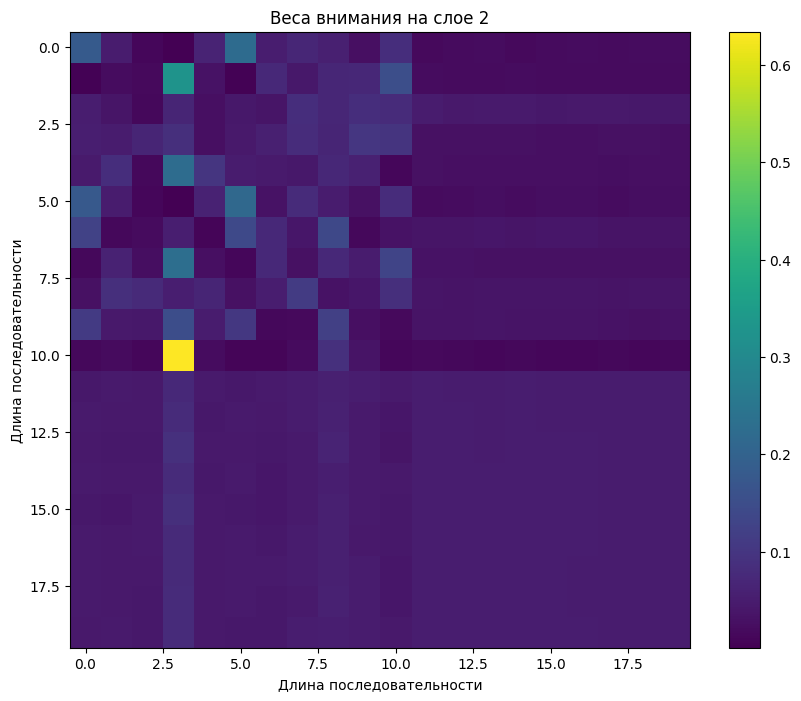

In [9]:
model.eval()

X_example, _ = next(iter(test_data))

with torch.no_grad():
    a = model(X_example)

def plot_attention_weights(weights, layer):
    attention = weights[layer]
    attention = attention[0].mean(dim=0).numpy()

    plt.figure(figsize=(10, 8))
    plt.imshow(attention, cmap='viridis', aspect = 'auto')
    plt.colorbar()
    plt.title(f"Веса внимания на слое {layer + 1}")
    plt.xlabel("Длина последовательности")
    plt.ylabel("Длина последовательности")
    plt.show()

for layer in range(len(model.attention_weights)):
    plot_attention_weights(model.attention_weights, layer)

На графике видно, что основное внимание модели сосредоточено на первой половине последовательности. Это связано с тем, что тексты в датасете являются короткими, а оставшаяся часть последовательности заполнена токенами паддинга. Яркие области соответствуют словам, которые модель считает наиболее информативными для определения эмоциональной окраски текста. Графики для первого и второго слоя имеют схожую структуру, то есть оба слоя выделяют похожие зависимости между словами. 

3. Сделать выводы о том, как модель воспринимает данные и принимает решения

посмотрим насколько уверенно модель принимает решения:

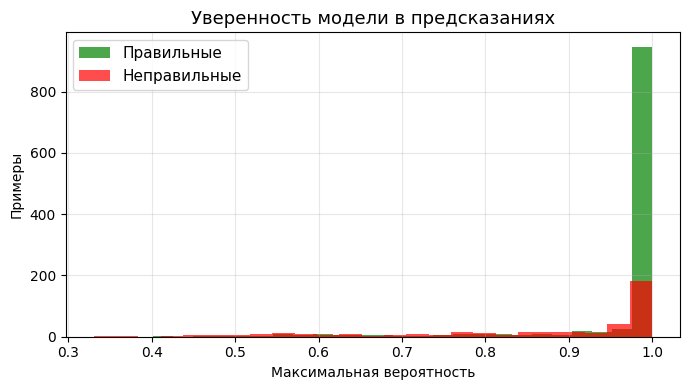

Доля высокоуверенных предсказаний: 0.836
Средняя уверенность правильных:  0.9689780473709106
Средняя уверенность неправильных: 0.8756781220436096


In [10]:
all_probs = []
all_preds = []
all_true  = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_data:
        output = model(X_batch)
        probs = torch.softmax(output, dim=1)
        preds = probs.argmax(dim=1)
        all_probs.append(probs)
        all_preds.append(preds)
        all_true.append(y_batch)

all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy()
all_true  = torch.cat(all_true).numpy()
confidence = all_probs.max(axis=1)


correct_mask = (all_preds == all_true)
plt.figure(figsize=(7, 4))
plt.hist(confidence[correct_mask],  bins=25, alpha=0.7, color='green', label='Правильные')
plt.hist(confidence[~correct_mask], bins=25, alpha=0.7, color='red',   label='Неправильные')
plt.title('Уверенность модели в предсказаниях', fontsize=13)
plt.xlabel('Максимальная вероятность')
plt.ylabel('Примеры')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Доля высокоуверенных предсказаний: {(confidence > 0.9).mean()}")
print(f"Средняя уверенность правильных:  {confidence[correct_mask].mean()}")
print(f"Средняя уверенность неправильных: {confidence[~correct_mask].mean()}")

И посмотрим на матрицу ошибок:

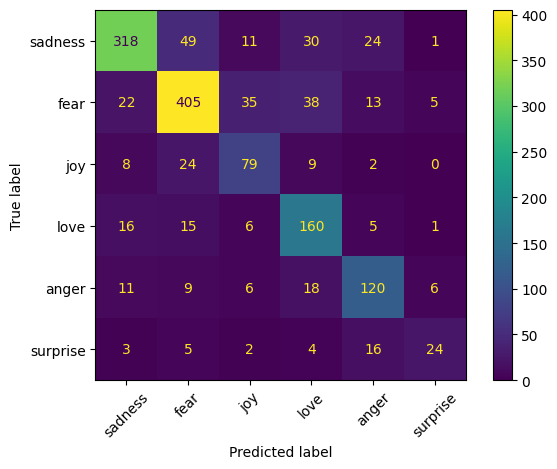

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    all_true,
    all_preds,
    display_labels=['sadness', 'fear', 'joy', 'love', 'anger', 'surprise'],
    xticks_rotation=45
)
plt.tight_layout()
plt.show()



## Выводы

Модель достигает точности $\approx 70–75\%$ при обучении всего на 5 000 примерах за 30 эпох.

По графику распределения уверенности верных и ошибочных предсказаний видно, что когда модель "уверена", то она, как правило,оказывается права.
В матрице ошибок диагональ матрицы доминирует по всем классам, что подтверждает общую работоспособность модели. Наибольшее число ошибок сосредоточено в парах схожих эмоций: `love` путается с `joy`, а `sadness` с `fear`. Это происходит потому, что граница между такими эмоциями размыта, и для их описания часто используются схожие слова.

В целом трансформер успешно решает задачу классификации коротких эмоциональных текстов, опираясь на лексические маркеры эмоций и контекстуальные связи между словами. Механизм самовнимания позволяет модели выделять ключевые слова независимо от их позиции в предложении, что позволяет давать более точные предсказания. 
